when building a machine learning model there are 3 steps.
1. perpare the data
- import the data
- explore the data
- split the data- some of the data will be used to test the model while the other to train the model.
2. build the model itself
- baseline- what is the minimum level of performance my model needs to achieve in order to add value
- iterate- build the model, check the model, make adjustments and repeate the process
- evaluate- evaluate the model
3. communicate the results

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from sklearn.linear_model import LinearRegression # used to buld the model
from sklearn.metrics import mean_absolute_error # used to evaluate the model

warnings.simplefilter(action='ignore', category = FutureWarning)

## Prepare data
### Import

In [66]:
def wrangle(filepath):
    # read csv file into DataFrame
    df= pd.read_csv(filepath)

    #subset to properties that are in Capital federal
    mask_ba = df['place_with_parent_names'].str.contains('Capital Federal')
    
    #subset to properties that are apartments
    mask_apt= df['property_type'] == 'apartment'

    # subset to properties less than $400,000 USD
    mask_price= df['price_aprox_usd'] < 400_000

    

    df = df[mask_ba & mask_apt & mask_price]

    # subset outliers by `surface_covered_in_m2`
    low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
    mask_area= df['surface_covered_in_m2'].between(low,high)
    df= df[mask_area]
    
    return df

In [67]:
df= wrangle(r"C:\Users\Peace\OneDrive\WorldQuant university projects\HOUSING IN BUENOS AIRES 2\Bueinos-Aires-Real_estate-1 - Sheet1.csv")
print(f'df shape : {df.shape}')
df.head()
# here the df is a global variable meaning it is not defined within the wrangle function

df shape : (1343, 17)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42


for this project, we want to build a model for apartments in buenos aires proper('Capital Federal) that cost less than $400,000. looking at the first five rows, we can tell that there are properties that fall outside thse parameters.
- task 1 is to remove those observations from our dataset. sinnce we are using a function to import the data, we will have to make adjustments to the function

the subsets are:
- only properties that are in CApital Federal- city of bueinos aires proper
- properties that cost less than $400,000
- we want only apartments

we are to take the whole dataframe and reduce it to fit these criteria

In [35]:
mask_ba= df['place_with_parent_names'].str.contains('Capital Federa')
mask_ba.head(10)
# the code points out the properties that are found in the capital.

0     True
4     True
9     True
11    True
20    True
29    True
38    True
40    True
41    True
48    True
Name: place_with_parent_names, dtype: bool

In [36]:
df[mask_ba].head(10)# this will show me a dataframe where all the properties involves are in bueinos aires proper

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...,1
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...,12
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...,21
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
38,sell,apartment,|Argentina|Capital Federal|Centro / Microcentro|,"-34.5985342536,-58.3727964943",78000.0,USD,1182667.2,78000.0,NaN,28.0,NaN,2785.714286,3.0,2.0,NaN,http://centro-microcentro.properati.com.ar/118...,39
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42
48,sell,apartment,|Argentina|Capital Federal|Almagro|,"-34.6038236,-58.4272911",138000.0,USD,2092411.2,138000.0,74.0,74.0,1864.864865,1864.864865,1.0,3.0,300,http://almagro.properati.com.ar/11w6t_venta_de...,49


criteria 2
#### 2) properties that are apartments

In [37]:
print(df['property_type'].nunique())
print(df['property_type'].unique())

1
['apartment']


In [38]:
mask_apt = df['property_type'] == 'apartment' 
mask_apt.head(10)
# this shows all the properties that are apartments

0     True
4     True
9     True
11    True
20    True
29    True
38    True
40    True
41    True
48    True
Name: property_type, dtype: bool

In [39]:
df[mask_apt].head(10) # this will show me a dataframe where all the properties involved are apartments

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...,1
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...,12
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...,21
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
38,sell,apartment,|Argentina|Capital Federal|Centro / Microcentro|,"-34.5985342536,-58.3727964943",78000.0,USD,1182667.2,78000.0,NaN,28.0,NaN,2785.714286,3.0,2.0,NaN,http://centro-microcentro.properati.com.ar/118...,39
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42
48,sell,apartment,|Argentina|Capital Federal|Almagro|,"-34.6038236,-58.4272911",138000.0,USD,2092411.2,138000.0,74.0,74.0,1864.864865,1864.864865,1.0,3.0,300,http://almagro.properati.com.ar/11w6t_venta_de...,49


ciretia 3
#### 4) properties that are less than $400,000 USD

In [40]:
mask_price = df['price_aprox_usd'] < 400_000
mask_price.head(10)

0     True
4     True
9     True
11    True
20    True
29    True
38    True
40    True
41    True
48    True
Name: price_aprox_usd, dtype: bool

In [78]:
mask_price = (df['price_aprox_usd'] < 400_000).sum()
print(mask_price)

1343


In [41]:
df[mask_price].head(10)

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...,1
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...,12
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...,21
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
38,sell,apartment,|Argentina|Capital Federal|Centro / Microcentro|,"-34.5985342536,-58.3727964943",78000.0,USD,1182667.2,78000.0,NaN,28.0,NaN,2785.714286,3.0,2.0,NaN,http://centro-microcentro.properati.com.ar/118...,39
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42
48,sell,apartment,|Argentina|Capital Federal|Almagro|,"-34.6038236,-58.4272911",138000.0,USD,2092411.2,138000.0,74.0,74.0,1864.864865,1864.864865,1.0,3.0,300,http://almagro.properati.com.ar/11w6t_venta_de...,49


In [42]:
df[mask_price].shape

(1781, 17)

## exploring the data

now that we are done with importing the data, we need to explore the data

from the previous project , we saw that property size is an important factor in determining the price of a property. so with that in mnd we need to look at the distrubution of our property sizes. 
- we use a histogram

#### we begin by looking at the surfaace area


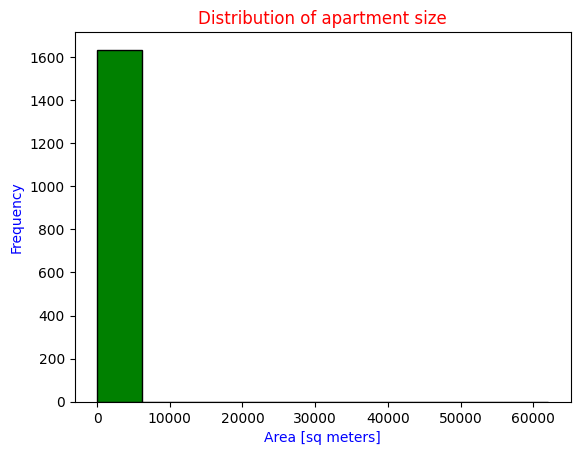

In [47]:
plt.hist(df['surface_covered_in_m2'],color='green',edgecolor='black')
plt.xlabel('Area [sq meters]',color='blue')
plt.ylabel('Frequency',color='blue')
plt.title('Distribution of apartment size',color='red');
# this unfiltered version of the graph shows that there are outliers in the data. 
# there are properties that ave very llarge as compared to the majourity of the properties

In [49]:
df['surface_covered_in_m2'].describe()

count     1635.000000
mean        97.877064
std       1533.057610
min          0.000000
25%         38.000000
50%         50.000000
75%         73.000000
max      62034.000000
Name: surface_covered_in_m2, dtype: float64

- we have a minimum of zero- which is wired because you do not sell apartments whose area is zero

- at he same time we have maximum of 62034 which is big .yet the mean is 97.8

- when u look at the median,  50% of the properties are 50m2 and below

- 75% of the properties are 73m2 and below then you have this large property that is 62034m2

- the mean is around 100 but the standard deviation(the spread) is 1500

        - It suggests one or more of the following:

         -The data has very high variability.

         -There may be extreme outliers (very large or very small values).

         -The mean may not be a good measure of the "typical" value, because a few extreme values can pull it away from where most of the data lies.

#### this shows that the data is spread out. it is skewed

In [51]:
""" we remove the outliers by picking the properties that are within the 90th and the 10th percentile"""

df['surface_covered_in_m2'].quantile([0.1,0.9])

0.1     31.0
0.9    100.0
Name: surface_covered_in_m2, dtype: float64

In [53]:
low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
print(f'{low}, {high}')

31.0, 100.0


In [60]:
low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
mask_area= df['surface_covered_in_m2'].between(low,high)
df[mask_area].head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42


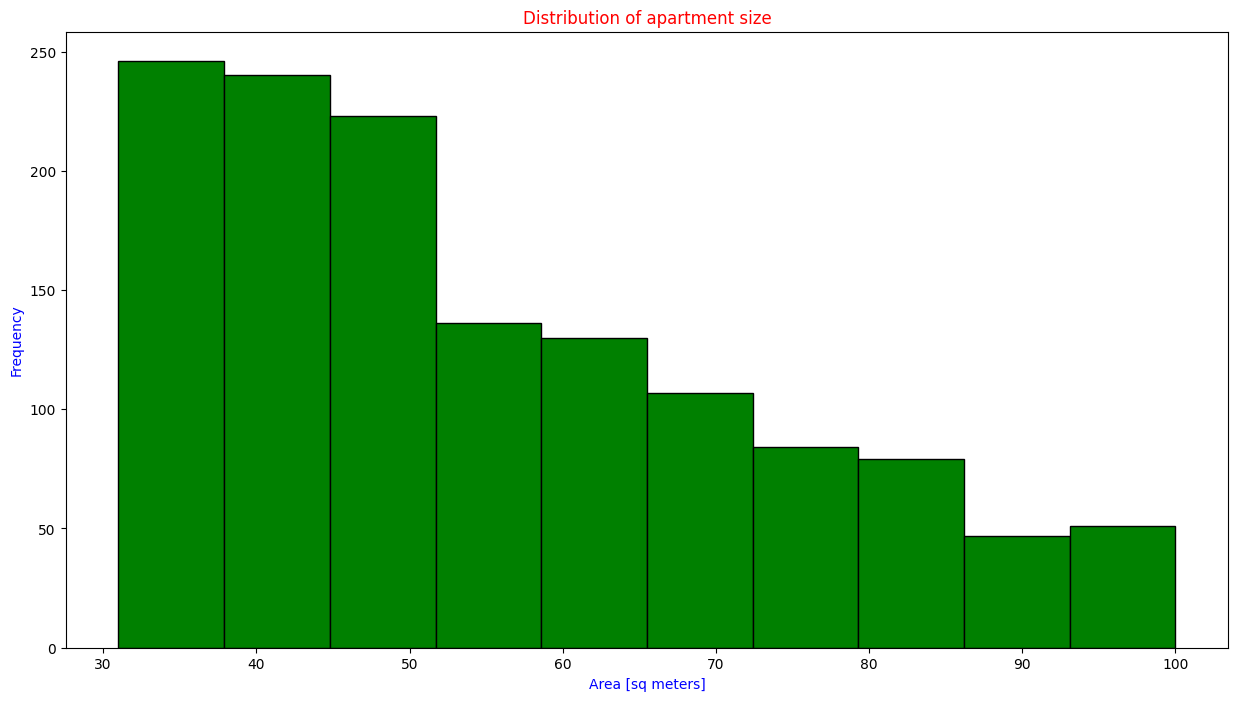

In [79]:
# using the data that is free of outliers we have this histogram
plt.figure(figsize=(15,8))
plt.hist(df['surface_covered_in_m2'],color='green',edgecolor='black')
plt.xlabel('Area [sq meters]',color='blue')
plt.ylabel('Frequency',color='blue')
plt.title('Distribution of apartment size',color='red');

now that the data is free of outliers, it is time to explore the relationship between appartment size and price

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 4 to 8604
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   1343 non-null   object 
 1   property_type               1343 non-null   object 
 2   place_with_parent_names     1343 non-null   object 
 3   lat-lon                     1300 non-null   object 
 4   price                       1343 non-null   float64
 5   currency                    1343 non-null   object 
 6   price_aprox_local_currency  1343 non-null   float64
 7   price_aprox_usd             1343 non-null   float64
 8   surface_total_in_m2         965 non-null    float64
 9   surface_covered_in_m2       1343 non-null   float64
 10  price_usd_per_m2            927 non-null    float64
 11  price_per_m2                1343 non-null   float64
 12  floor                       379 non-null    float64
 13  rooms                       1078 non-n

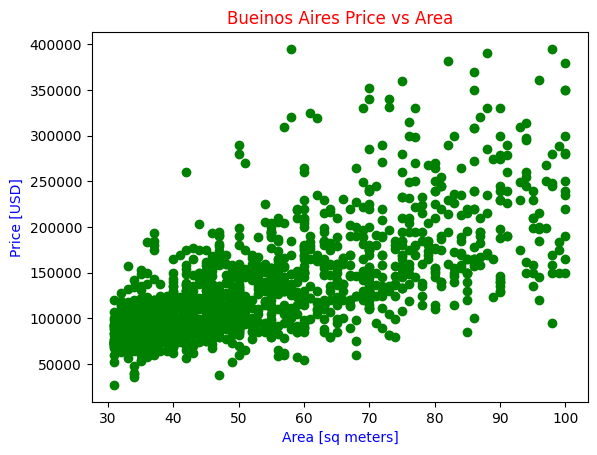

In [75]:
plt.scatter(x=df['surface_covered_in_m2'],y=df['price_aprox_usd'],color='green')
plt.xlabel('Area [sq meters]', color= 'blue')
plt.ylabel('Price [USD]',color='blue')
plt.title('Bueinos Aires Price vs Area', color= 'red');

In [76]:
correlation= df['surface_covered_in_m2'].corr(df['price_aprox_usd'])
print(correlation)

0.6868188329865075


the correlation between the price and the area is positive and it is above 0.5 meaning it is a moderately positive relationship

## linear model
linear models are about straight lines and are concerened with distance. it is all about trying to draw data that best fits the data ( in our case a that best describes the relationship between the price and size of the appartment). it is mainly about daawing the line that describes the data and minimizing the distance between the straight line and the data

## split
we have done importing then exploring now we are at split
a key part of model building, is separating your target( the ting you want to predict) from your features( the information your model will use to make predictions).
- target - the thing you want to predict
- features - the information your model wll use to make predictions

- The Feature matrix is always represented by X (upper case x).
feature matrix usually has many columns but for our case we will use onr column 
- Target vector is always represented by y ( lower case y)

Create a feature matrix named "X_train" which we will use to train the model. it should contain one feature only['surface_covered_in_m2]. the feature matrix should always be two dimensional